# Generative Adversarial Networks From Scratch

This notebook builds a tiny Generative Adversarial Network (GAN) with only NumPy. The goal is not to win a benchmark. The goal is to see the mechanics clearly: the probability model, the loss functions, the gradients, and the training loop.

Real-life picture: imagine a counterfeit artist and a bank inspector.

- The **generator** is the artist. It starts by producing bad counterfeits, then improves by studying which fakes fooled the inspector.
- The **discriminator** is the inspector. It sees real examples and generated examples, then learns to classify each one as real or fake.
- Training is adversarial because each network improves against the other.

For a small runnable example, the "real world" is package delivery time in hours. Real delivery times have two common patterns: fast city deliveries and slower weekend/rural deliveries. The GAN sees only samples and learns to generate delivery times that look like the same distribution.


## Goal

By the end, you should be able to explain and run a GAN from scratch:

1. Define the generator `G_phi(z)` and discriminator `D_theta(x)`.
2. Write the GAN objective mathematically.
3. Derive the gradients used for binary cross-entropy and dense layers.
4. Train both networks with NumPy only.
5. Check whether generated samples match the real delivery-time distribution.

We use a one-dimensional dataset because the math is easier to see. The same idea scales to images, audio, and text embeddings, but larger models use the same core loop.


## Setup

The notebook uses only:

- `numpy` for arrays, neural-network layers, gradients, and Adam updates.
- `matplotlib` for visual checks.

No PyTorch, TensorFlow, or scikit-learn is used.


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
plt.style.use("seaborn-v0_8-whitegrid")

EPS = 1e-8


## Step 1: The Data Distribution

A GAN learns a **distribution**, not a single correct answer.

In this toy real-life setting, each sample is a package delivery time in hours:

- Most packages arrive quickly, around 28 hours.
- Some arrive slowly, around 72 hours.

That creates a two-peak distribution. The generator's job is to produce numbers with similar peaks and spread.

For stable neural-network training, we normalize hours into a smaller numeric range:

$$
 x_{norm} = \frac{x_{hours} - 50}{25}
$$

and convert back with:

$$
 x_{hours} = 25x_{norm} + 50
$$


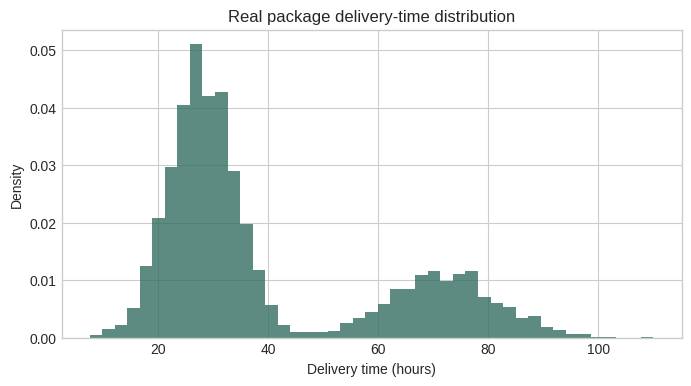

Mean delivery time: 40.1 hours
Standard deviation: 21.0 hours
10th / 50th / 90th percentile: [21.3 31.1 75.4]


In [2]:
DELIVERY_CENTER = 50.0
DELIVERY_SCALE = 25.0


def normalize_hours(hours):
    return (hours - DELIVERY_CENTER) / DELIVERY_SCALE


def denormalize_hours(normalized_values):
    return normalized_values * DELIVERY_SCALE + DELIVERY_CENTER


def sample_real_delivery_hours(n, random_state):
    """Sample a two-mode real-life-like delivery-time distribution."""
    route_type = random_state.random(n) < 0.72
    fast_city = random_state.normal(loc=28.0, scale=6.0, size=n)
    slow_weekend = random_state.normal(loc=72.0, scale=10.0, size=n)
    hours = np.where(route_type, fast_city, slow_weekend)
    return np.clip(hours, 6.0, 110.0).reshape(-1, 1)


def sample_real_normalized(n, random_state):
    return normalize_hours(sample_real_delivery_hours(n, random_state))


real_preview = sample_real_delivery_hours(5_000, rng)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(real_preview, bins=45, density=True, color="#2F6B5F", alpha=0.78)
ax.set_title("Real package delivery-time distribution")
ax.set_xlabel("Delivery time (hours)")
ax.set_ylabel("Density")
plt.show()

print(f"Mean delivery time: {real_preview.mean():.1f} hours")
print(f"Standard deviation: {real_preview.std():.1f} hours")
print(f"10th / 50th / 90th percentile: {np.percentile(real_preview, [10, 50, 90]).round(1)}")


## Step 2: GAN Math

Let:

- `x ~ p_data(x)` be a real delivery time.
- `z ~ p_z(z)` be random noise, usually a standard normal sample.
- `G_phi(z)` be the generator output: a fake delivery time.
- `D_theta(x)` be the discriminator output: the estimated probability that `x` is real.

The original GAN game is:

$$
\min_{G} \max_{D} V(D, G) =
\mathbb{E}_{x \sim p_{data}}[\log D(x)] +
\mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]
$$

The discriminator wants to maximize both terms:

- Real samples should produce `D(x)` close to `1`.
- Fake samples should produce `D(G(z))` close to `0`.

The generator wants the opposite: fake samples should produce `D(G(z))` close to `1`.

In practice, we minimize losses. For a minibatch of size `m`, the discriminator loss is binary cross-entropy:

$$
L_D = -\frac{1}{m}\sum_{i=1}^{m}
\left[y_i\log(p_i) + (1-y_i)\log(1-p_i)\right]
$$

where real samples use `y=1` and fake samples use `y=0`.

For the generator, we use the common **non-saturating** loss:

$$
L_G = -\frac{1}{m}\sum_{i=1}^{m}\log(D(G(z_i)))
$$

This tells the generator: "make the discriminator believe your fake sample is real."


## Step 3: The Gradients We Need

The discriminator ends with a sigmoid:

$$
 p = \sigma(a) = \frac{1}{1 + e^{-a}}
$$

For binary cross-entropy with sigmoid, the derivative is simple:

$$
\frac{\partial L}{\partial a} = \frac{p - y}{m}
$$

For a dense layer:

$$
Y = XW + b
$$

if upstream gradient is `dY`, then:

$$
\frac{\partial L}{\partial W} = X^T dY
$$

$$
\frac{\partial L}{\partial b} = \sum dY
$$

$$
\frac{\partial L}{\partial X} = dY W^T
$$

For `tanh`, the derivative is:

$$
\frac{d}{da}\tanh(a) = 1 - \tanh^2(a)
$$

That is enough to write the full backpropagation for both networks.


In [3]:
def sigmoid(values):
    values = np.clip(values, -50, 50)
    return 1.0 / (1.0 + np.exp(-values))


def binary_cross_entropy(probabilities, labels):
    probabilities = np.clip(probabilities, EPS, 1.0 - EPS)
    return -np.mean(labels * np.log(probabilities) + (1.0 - labels) * np.log(1.0 - probabilities))


def init_generator(random_state, noise_dim=2, hidden_dim=20):
    return {
        "W1": random_state.normal(0.0, math.sqrt(2.0 / noise_dim), size=(noise_dim, hidden_dim)),
        "b1": np.zeros((1, hidden_dim)),
        "W2": random_state.normal(0.0, math.sqrt(2.0 / hidden_dim), size=(hidden_dim, 1)),
        "b2": np.zeros((1, 1)),
    }


def init_discriminator(random_state, hidden_dim=20):
    return {
        "W1": random_state.normal(0.0, math.sqrt(2.0), size=(1, hidden_dim)),
        "b1": np.zeros((1, hidden_dim)),
        "W2": random_state.normal(0.0, math.sqrt(2.0 / hidden_dim), size=(hidden_dim, 1)),
        "b2": np.zeros((1, 1)),
    }


def generator_forward(noise, generator):
    hidden_pre = noise @ generator["W1"] + generator["b1"]
    hidden = np.tanh(hidden_pre)
    generated_x = hidden @ generator["W2"] + generator["b2"]
    cache = {"noise": noise, "hidden": hidden, "generated_x": generated_x}
    return generated_x, cache


def discriminator_forward(samples, discriminator):
    hidden_pre = samples @ discriminator["W1"] + discriminator["b1"]
    hidden = np.tanh(hidden_pre)
    logits = hidden @ discriminator["W2"] + discriminator["b2"]
    probabilities = sigmoid(logits)
    cache = {"samples": samples, "hidden": hidden, "logits": logits, "probabilities": probabilities}
    return probabilities, cache


## Step 4: Backpropagation From Scratch

The discriminator backward pass updates discriminator weights.

The generator backward pass is slightly different:

1. Send fake samples through the discriminator.
2. Compute the generator loss as if fake samples had label `1`.
3. Backpropagate through the discriminator only to get `dL/d(fake_sample)`.
4. Freeze discriminator weights and update only generator weights.

This is why GAN training alternates between discriminator and generator updates.


In [4]:
def discriminator_backward(cache, labels, discriminator):
    probabilities = cache["probabilities"]
    samples = cache["samples"]
    hidden = cache["hidden"]
    batch_size = labels.shape[0]

    dlogits = (probabilities - labels) / batch_size
    dW2 = hidden.T @ dlogits
    db2 = np.sum(dlogits, axis=0, keepdims=True)

    dhidden = dlogits @ discriminator["W2"].T
    dhidden_pre = dhidden * (1.0 - hidden**2)
    dW1 = samples.T @ dhidden_pre
    db1 = np.sum(dhidden_pre, axis=0, keepdims=True)

    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}


def discriminator_input_gradient(cache, labels, discriminator):
    """Return dL/dx while keeping discriminator parameters frozen."""
    probabilities = cache["probabilities"]
    hidden = cache["hidden"]
    batch_size = labels.shape[0]

    dlogits = (probabilities - labels) / batch_size
    dhidden = dlogits @ discriminator["W2"].T
    dhidden_pre = dhidden * (1.0 - hidden**2)
    dsamples = dhidden_pre @ discriminator["W1"].T
    return dsamples


def generator_backward(cache, dgenerated_x, generator):
    noise = cache["noise"]
    hidden = cache["hidden"]

    dW2 = hidden.T @ dgenerated_x
    db2 = np.sum(dgenerated_x, axis=0, keepdims=True)

    dhidden = dgenerated_x @ generator["W2"].T
    dhidden_pre = dhidden * (1.0 - hidden**2)
    dW1 = noise.T @ dhidden_pre
    db1 = np.sum(dhidden_pre, axis=0, keepdims=True)

    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}


## Step 5: Optimizer From Scratch

Plain gradient descent can work, but GANs are sensitive because both networks are moving targets. We use Adam, which keeps moving averages of gradients and squared gradients.

For each parameter `w` at step `t`:

$$
 m_t = \beta_1m_{t-1} + (1 - \beta_1)g_t
$$

$$
 v_t = \beta_2v_{t-1} + (1 - \beta_2)g_t^2
$$

Bias correction:

$$
 \hat{m}_t = \frac{m_t}{1 - \beta_1^t}
$$

$$
 \hat{v}_t = \frac{v_t}{1 - \beta_2^t}
$$

Update:

$$
 w_t = w_{t-1} - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
$$


In [5]:
def init_adam_state(parameters):
    return {
        "m": {name: np.zeros_like(value) for name, value in parameters.items()},
        "v": {name: np.zeros_like(value) for name, value in parameters.items()},
        "t": 0,
    }


def adam_step(parameters, gradients, state, learning_rate, beta1=0.5, beta2=0.999):
    state["t"] += 1
    t = state["t"]

    for name, gradient in gradients.items():
        state["m"][name] = beta1 * state["m"][name] + (1.0 - beta1) * gradient
        state["v"][name] = beta2 * state["v"][name] + (1.0 - beta2) * (gradient**2)

        m_hat = state["m"][name] / (1.0 - beta1**t)
        v_hat = state["v"][name] / (1.0 - beta2**t)
        parameters[name] -= learning_rate * m_hat / (np.sqrt(v_hat) + EPS)


## Step 6: Train the GAN

One training iteration has two phases.

**Discriminator phase**

1. Draw real samples `x`.
2. Draw noise `z` and create fake samples `G(z)`.
3. Train `D` to output `1` for real and `0` for fake.

**Generator phase**

1. Draw new noise `z` and create fake samples `G(z)`.
2. Send fake samples through `D`.
3. Train `G` so `D(G(z))` moves toward `1`.

The two losses do not have to decrease smoothly. GAN training is a game, not ordinary single-model supervised learning.


In [6]:
noise_dim = 2
batch_size = 128
training_steps = 4_000
learning_rate_d = 0.0015
learning_rate_g = 0.0015

train_rng = np.random.default_rng(123)
generator = init_generator(train_rng, noise_dim=noise_dim, hidden_dim=24)
discriminator = init_discriminator(train_rng, hidden_dim=24)
generator_adam = init_adam_state(generator)
discriminator_adam = init_adam_state(discriminator)

history = {"step": [], "d_loss": [], "g_loss": [], "d_real_mean": [], "d_fake_mean": []}

for step in range(1, training_steps + 1):
    # 1. Train discriminator.
    real_samples = sample_real_normalized(batch_size, train_rng)
    noise = train_rng.normal(0.0, 1.0, size=(batch_size, noise_dim))
    fake_samples, _ = generator_forward(noise, generator)

    discriminator_samples = np.vstack([real_samples, fake_samples])
    discriminator_labels = np.vstack([np.ones((batch_size, 1)), np.zeros((batch_size, 1))])
    discriminator_probabilities, discriminator_cache = discriminator_forward(discriminator_samples, discriminator)
    d_loss = binary_cross_entropy(discriminator_probabilities, discriminator_labels)
    d_gradients = discriminator_backward(discriminator_cache, discriminator_labels, discriminator)
    adam_step(discriminator, d_gradients, discriminator_adam, learning_rate_d)

    # 2. Train generator against the current frozen discriminator.
    noise = train_rng.normal(0.0, 1.0, size=(batch_size, noise_dim))
    fake_samples, generator_cache = generator_forward(noise, generator)
    fake_probabilities, fake_cache = discriminator_forward(fake_samples, discriminator)
    generator_target_labels = np.ones((batch_size, 1))
    g_loss = binary_cross_entropy(fake_probabilities, generator_target_labels)

    dfake_samples = discriminator_input_gradient(fake_cache, generator_target_labels, discriminator)
    g_gradients = generator_backward(generator_cache, dfake_samples, generator)
    adam_step(generator, g_gradients, generator_adam, learning_rate_g)

    if step == 1 or step % 100 == 0:
        real_probabilities, _ = discriminator_forward(real_samples, discriminator)
        generated_check, _ = generator_forward(train_rng.normal(0.0, 1.0, size=(batch_size, noise_dim)), generator)
        fake_check_probabilities, _ = discriminator_forward(generated_check, discriminator)
        history["step"].append(step)
        history["d_loss"].append(float(d_loss))
        history["g_loss"].append(float(g_loss))
        history["d_real_mean"].append(float(real_probabilities.mean()))
        history["d_fake_mean"].append(float(fake_check_probabilities.mean()))

print(f"Final discriminator loss: {history['d_loss'][-1]:.3f}")
print(f"Final generator loss: {history['g_loss'][-1]:.3f}")
print(f"D(real) mean: {history['d_real_mean'][-1]:.3f}")
print(f"D(fake) mean: {history['d_fake_mean'][-1]:.3f}")


Final discriminator loss: 0.692
Final generator loss: 0.693
D(real) mean: 0.502
D(fake) mean: 0.504


## Step 7: Read the Training Signals

A perfect discriminator would output:

- `D(real) = 1`
- `D(fake) = 0`

At GAN equilibrium, generated samples match real samples. Then the discriminator cannot tell them apart, so:

$$
D(x) \approx 0.5
$$

This does **not** mean the discriminator is bad. It means the game has become hard because fake samples look realistic under the learned features.


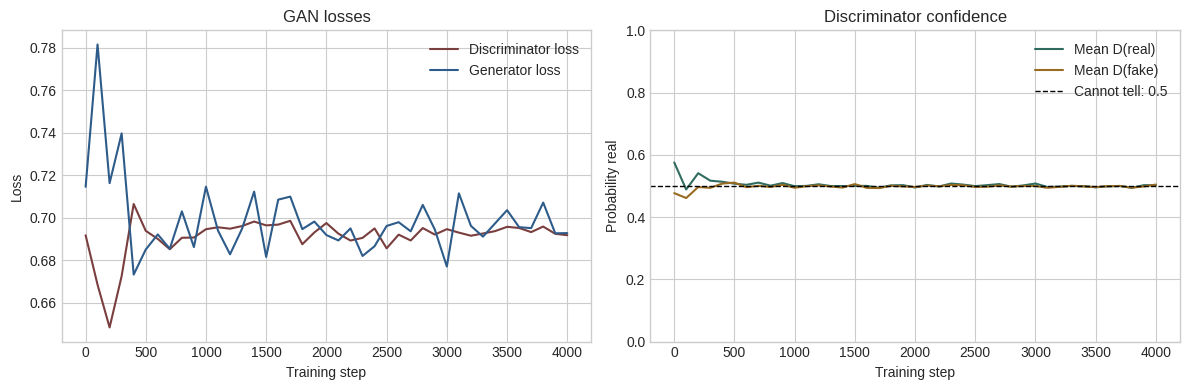

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["step"], history["d_loss"], label="Discriminator loss", color="#7A3E3E")
axes[0].plot(history["step"], history["g_loss"], label="Generator loss", color="#2E5C8A")
axes[0].set_title("GAN losses")
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["step"], history["d_real_mean"], label="Mean D(real)", color="#2F6B5F")
axes[1].plot(history["step"], history["d_fake_mean"], label="Mean D(fake)", color="#9A6B22")
axes[1].axhline(0.5, color="black", linestyle="--", linewidth=1, label="Cannot tell: 0.5")
axes[1].set_title("Discriminator confidence")
axes[1].set_xlabel("Training step")
axes[1].set_ylabel("Probability real")
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()


## Step 8: Compare Real and Generated Samples

The clearest check is distribution matching.

The generator never receives the formula for the real distribution. It only receives gradients from the discriminator. If training worked, generated delivery times should concentrate around similar hour ranges as the real samples.


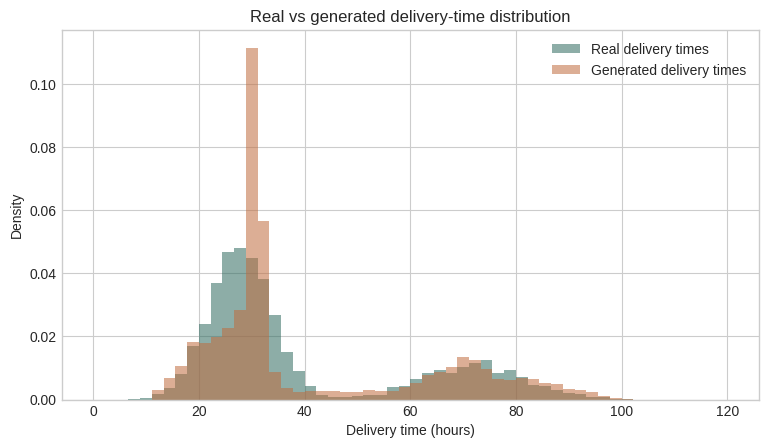

Percentiles: 10th, 25th, 50th, 75th, 90th
Real:      [21.4 25.5 30.8 58.5 75.2]
Generated: [20.9 27.8 30.9 60.8 76.1]
Real mean / std:      39.9 / 21.0 hours
Generated mean / std: 41.0 / 21.5 hours


In [8]:
evaluation_rng = np.random.default_rng(999)
real_eval = sample_real_delivery_hours(8_000, evaluation_rng)
noise = evaluation_rng.normal(0.0, 1.0, size=(8_000, noise_dim))
generated_normalized, _ = generator_forward(noise, generator)
generated_hours = np.clip(denormalize_hours(generated_normalized), 0.0, 130.0)

fig, ax = plt.subplots(figsize=(9, 4.8))
bins = np.linspace(0, 120, 55)
ax.hist(real_eval, bins=bins, density=True, alpha=0.55, label="Real delivery times", color="#2F6B5F")
ax.hist(generated_hours, bins=bins, density=True, alpha=0.55, label="Generated delivery times", color="#C06C3E")
ax.set_title("Real vs generated delivery-time distribution")
ax.set_xlabel("Delivery time (hours)")
ax.set_ylabel("Density")
ax.legend()
plt.show()

real_stats = np.percentile(real_eval, [10, 25, 50, 75, 90]).round(1)
generated_stats = np.percentile(generated_hours, [10, 25, 50, 75, 90]).round(1)

print("Percentiles: 10th, 25th, 50th, 75th, 90th")
print(f"Real:      {real_stats}")
print(f"Generated: {generated_stats}")
print(f"Real mean / std:      {real_eval.mean():.1f} / {real_eval.std():.1f} hours")
print(f"Generated mean / std: {generated_hours.mean():.1f} / {generated_hours.std():.1f} hours")


## Step 9: Inspect the Discriminator Boundary

The discriminator is a learned real/fake detector over possible delivery times.

If generated samples are poor, the discriminator usually has obvious regions where it says "fake" with high confidence. If generated samples overlap real samples, the discriminator becomes less certain.


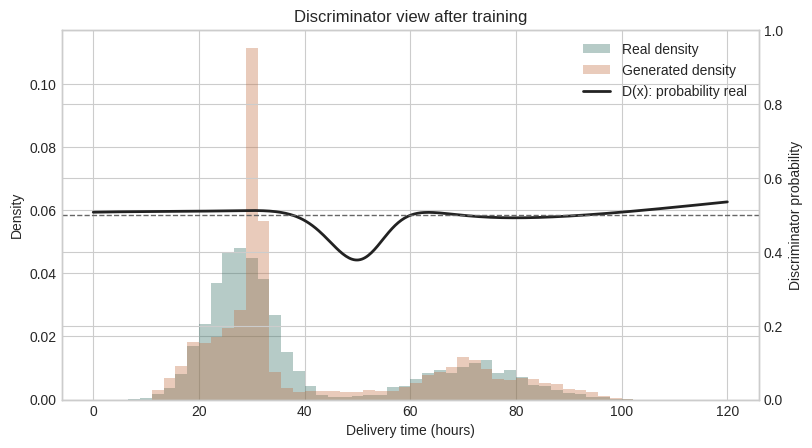

In [9]:
grid_hours = np.linspace(0, 120, 400).reshape(-1, 1)
grid_normalized = normalize_hours(grid_hours)
grid_probabilities, _ = discriminator_forward(grid_normalized, discriminator)

fig, ax1 = plt.subplots(figsize=(9, 4.8))
ax1.hist(real_eval, bins=bins, density=True, alpha=0.35, label="Real density", color="#2F6B5F")
ax1.hist(generated_hours, bins=bins, density=True, alpha=0.35, label="Generated density", color="#C06C3E")
ax1.set_xlabel("Delivery time (hours)")
ax1.set_ylabel("Density")

ax2 = ax1.twinx()
ax2.plot(grid_hours.ravel(), grid_probabilities.ravel(), color="#222222", linewidth=2, label="D(x): probability real")
ax2.axhline(0.5, color="#666666", linestyle="--", linewidth=1)
ax2.set_ylabel("Discriminator probability")
ax2.set_ylim(0, 1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
ax1.set_title("Discriminator view after training")
plt.show()


## Checks

Use these checks to reason about whether training worked.

1. **Shape check**: generated delivery times should sit mostly inside a realistic range, not explode to huge values.
2. **Distribution check**: the generated histogram should overlap the real histogram.
3. **Percentile check**: generated median and spread should be close to real median and spread.
4. **Discriminator check**: `D(real)` and `D(fake)` moving toward each other means the discriminator is less able to separate them.

GANs can be unstable. If your generated histogram covers only one peak, that is called **mode collapse**. It means the generator found one pattern that fools the discriminator often enough and ignored other valid patterns.


In [10]:
def summarize_quality(real_values, generated_values):
    real_values = np.asarray(real_values).reshape(-1)
    generated_values = np.asarray(generated_values).reshape(-1)

    real_percentiles = np.percentile(real_values, [10, 50, 90])
    generated_percentiles = np.percentile(generated_values, [10, 50, 90])
    percentile_gap = np.abs(real_percentiles - generated_percentiles)
    mean_gap = abs(real_values.mean() - generated_values.mean())
    std_gap = abs(real_values.std() - generated_values.std())

    return {
        "mean_gap_hours": float(mean_gap),
        "std_gap_hours": float(std_gap),
        "p10_gap_hours": float(percentile_gap[0]),
        "p50_gap_hours": float(percentile_gap[1]),
        "p90_gap_hours": float(percentile_gap[2]),
    }


quality = summarize_quality(real_eval, generated_hours)
for metric, value in quality.items():
    print(f"{metric}: {value:.2f}")

assert generated_hours.shape == real_eval.shape
assert np.isfinite(generated_hours).all()
assert generated_hours.min() >= 0.0
print("Basic runtime checks passed.")


mean_gap_hours: 1.02
std_gap_hours: 0.58
p10_gap_hours: 0.51
p50_gap_hours: 0.09
p90_gap_hours: 0.90
Basic runtime checks passed.


## What Changed Compared With Ordinary Neural Networks?

In supervised learning, a model receives a fixed target label. For example, a classifier might learn that an image is a cat.

In a GAN, the target moves:

- The discriminator keeps changing because it gets better at detecting fakes.
- The generator keeps changing because it adapts to the discriminator's weaknesses.

That moving-target setup is why GANs are powerful but hard to train.

A useful mental model:

- `D` learns the current difference between real and fake.
- `G` uses that difference as a training signal.
- When `G` becomes realistic, `D` loses its easy shortcuts.


## Next Steps

To extend this notebook:

1. Replace the synthetic delivery-time sampler with a real dataset, such as transaction amounts, wait times, or sensor readings.
2. Increase the output dimension from one number to multiple features.
3. Try image data and replace dense layers with convolutional layers.
4. Add training safeguards such as label smoothing, gradient penalty, or Wasserstein loss.
5. Run the notebook several times with different seeds to see how GAN instability appears in practice.

Key idea to remember:

> A GAN learns to generate realistic samples by turning the discriminator's mistakes into the generator's learning signal.
